# Model Architectures of Neural Networks
The following notebook contains code that we used to evaluate various model architectures. This code will, when given a model architecture, output the model's training and test loss at given points. We then recorded these loss values manually (see `results/`), before analyzing this data in R (`figures/`). 

This notebook takes in genetic data from a viral sample in the form of a `.fasta` file. The dataset used is the "much larger" simulated dataset of approximately 23,000 sequences that can be found in the `simulations` folder.

In [1]:
from Bio import SeqIO
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import matplotlib.pyplot as plt


alignment = list(SeqIO.parse('../../simulations/results/simulated_alignment_much_larger.fasta', 'fasta'))
metadata = pd.read_csv('../../simulations/results/simulated_metadata_much_larger.csv')

In [2]:
#Set to ensure reproducability
torch.manual_seed(77) #We recorded model loss at two seed values: 77 and 78, by manually changing this value
torch.use_deterministic_algorithms(True)
np.random.seed(77)

## Data Wrangling
In order for the model to be able to read the sequence data in the `.fasta` file, we must convert the strings of ATCG into 1s and 0s through **one-hot encoding**

In [3]:
#Encodes one sequence
def oneHotEncode(seq): 
    seq2=list()
    mapping = {"A":[1.0, 0.0, 0.0, 0.], "T": [0.0, 1.0, 0.0, 0.0], "C": [0.0, 0.0, 1.0, 0.0], "G":[0.0, 0.0, 0.0, 1.0]}
    for i in seq:
        seq2.append(mapping[i] if i in mapping.keys() else [0., 0., 0., 0.])
    return np.array(seq2).flatten()

#Iterating encode function across an entire dataset
def encodeSet(dataList):
    set2 = list()
    for i in range(len(dataList)):
        set2.append(oneHotEncode(dataList[i]))
    return np.array(set2)

In [4]:
#Encode the given dataset
sequenceEncoded = pd.DataFrame(encodeSet(alignment))
allData = pd.concat([sequenceEncoded, metadata['subgroup']], axis = 1)

To input the above dataframe into the neural network, we have to specify the labels and features of the dataset, split the data into testing and training pools, and make the data compatible with PyTorch via `DataLoader`.

In [5]:
#Splitting data into features (X) and label (Y, subgroups of A, B, C)
X = allData.drop('subgroup', axis = 1).values.astype(np.float32)
y = allData['subgroup'].values

#Transform the categorical subgroup data (A, B, C) into numerical (0, 1, 2), similar to one-hot encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y).astype(np.int64)

In [6]:
#Split data into test and train groups
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, train_size=0.8, shuffle=True)
#Toss out all but ~4,000 sequences of the train group
#The proportion of the "trash" group can be changed -- we also only kept ~2,000 sequences, and kept all of them
X_train, X_trash, y_train, y_trash = train_test_split(X_train, y_train, train_size = 0.21)

In [7]:
#Creating a PyTorch Dataset
#PyTorch can only read the data when it has been transformed into a tensor
class LocationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = LocationDataset(X_train, y_train)
test_dataset = LocationDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## The Model
Now that we have made our dataset readable by a neural network, we can define our model architecture and run the model to evaluate test/train loss.

In [8]:
num_epochs = 300 #Default 300, occassionally changed if the training loss hadn't converged at 300
dimensions = [32, 32] #Specify layer dimensions. Here, we have a 2x32 model.

In [9]:
#Create the model
layers = []
for i in range(len(dimensions)):
    if i == 0:
        layers.append(nn.Linear(len(sequenceEncoded.columns), dimensions[i]))
    else:
        layers.append(nn.Linear(dimensions[i-1], dimensions[i]))
    layers.append(nn.ReLU()) 

layers.append(nn.Linear(dimensions[-1], 3))

class Multiclass(nn.Module):
    def __init__(self, input_size, num_classes):
        super(Multiclass, self).__init__()
        self.model = nn.Sequential(
            *layers
        )
        #self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        logits = self.model(x)
        #return logits / self.temperature
        return logits

input_size = X.shape[1]
num_classes = len(np.unique(y_encoded))
model = Multiclass(input_size, num_classes)
print(model)

Multiclass(
  (model): Sequential(
    (0): Linear(in_features=20000, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [10]:
#Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

#Keep history of model
best_acc = - np.inf   # init to negative infinity
best_weights = None
train_loss_hist = []
train_acc_hist = []
test_loss_hist = []
test_acc_hist = []

In [11]:
#Train the model
def trainingLoop(epochs):
    for epoch in range(epochs):
        epoch_loss = []
        epoch_acc = []
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            #compute and store mectric
            acc = (torch.argmax(outputs, 1) == labels).float().mean()
            epoch_loss.append(float(loss))
            epoch_acc.append(float(acc))
        print(f'Epoch {epoch+1} - Loss {running_loss:.4f}')
        #Set model to evaluation mode
        model.eval()
        y_pred = model(torch.from_numpy(X_test))
        ce = criterion(y_pred, torch.from_numpy(y_test))
        acc = (torch.argmax(y_pred, 1) == torch.argmax(torch.from_numpy(y_test))).float().mean()
        ce = float(ce)
        acc = float(acc)
        train_loss_hist.append(np.mean(epoch_loss))
        train_acc_hist.append(np.mean(epoch_acc))
        test_loss_hist.append(ce)
        test_acc_hist.append(acc)

trainingLoop(num_epochs)

Epoch 1 - Loss 66.9100
Epoch 2 - Loss 66.2777
Epoch 3 - Loss 65.5163
Epoch 4 - Loss 64.5148
Epoch 5 - Loss 63.5937
Epoch 6 - Loss 63.3100
Epoch 7 - Loss 61.9239
Epoch 8 - Loss 60.9593
Epoch 9 - Loss 59.8290
Epoch 10 - Loss 59.1770
Epoch 11 - Loss 57.9034
Epoch 12 - Loss 57.1540
Epoch 13 - Loss 55.4558
Epoch 14 - Loss 54.7649
Epoch 15 - Loss 53.7483
Epoch 16 - Loss 51.8922
Epoch 17 - Loss 51.2032
Epoch 18 - Loss 49.8947
Epoch 19 - Loss 48.4732
Epoch 20 - Loss 47.2007
Epoch 21 - Loss 46.4782
Epoch 22 - Loss 44.8246
Epoch 23 - Loss 43.2443
Epoch 24 - Loss 42.1476
Epoch 25 - Loss 41.1526
Epoch 26 - Loss 39.5934
Epoch 27 - Loss 38.5595
Epoch 28 - Loss 37.6524
Epoch 29 - Loss 36.8141
Epoch 30 - Loss 35.2528
Epoch 31 - Loss 34.0021
Epoch 32 - Loss 32.9727
Epoch 33 - Loss 31.8018
Epoch 34 - Loss 31.1506
Epoch 35 - Loss 30.6283
Epoch 36 - Loss 29.2566
Epoch 37 - Loss 28.2310
Epoch 38 - Loss 27.5640
Epoch 39 - Loss 26.1892
Epoch 40 - Loss 25.4033
Epoch 41 - Loss 24.3882
Epoch 42 - Loss 23.5644
E

## Evaluating the Model
Once our model has been trained, we can evalute how the model performs on training and test data.

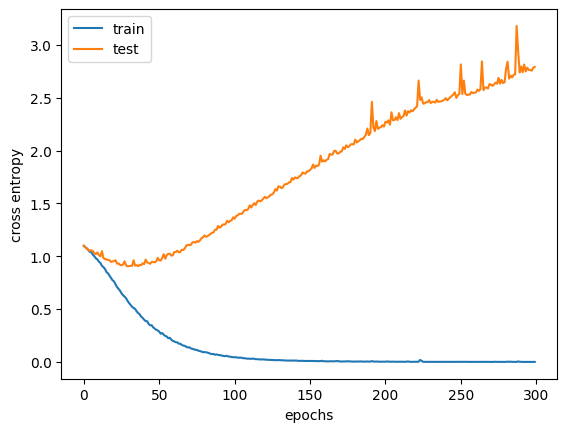

In [12]:
#Plot cross-entropy loss over epochs for test and train data
plt.plot(train_loss_hist, label="train")
plt.plot(test_loss_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

In [13]:
print("For model with architecture", dimensions)
test_loss_df = pd.DataFrame(test_loss_hist, columns = ["loss"])
test_loss_df = test_loss_df.reset_index()
train_loss_df = pd.DataFrame(train_loss_hist, columns = ["loss"])
print("Test Loss at 300 epochs:")
print(test_loss_hist[-1], "\n")

print("Train Loss at 300 epochs:")
print(train_loss_hist[-1])

For model with architecture [32, 32]
Test Loss at 300 epochs:
2.7921009063720703 

Train Loss at 300 epochs:
0.00030845013304210846
